In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [11]:
df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')

In [12]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [13]:
df.shape

(1025, 14)

In [22]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

In [15]:
df.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0


In [19]:
# Features and target selection
X = df.drop(columns = ['target'],axis = 1)
y = df['target']

In [34]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((820, 13), (205, 13), (820,), (205,))

In [35]:
# Initiating two classifiers 
logit_reg = LogisticRegression() 
decision_tree = DecisionTreeClassifier()

In [36]:
# Fit the models
logit_reg.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [37]:
logit_pred = logit_reg.predict(X_test)
decision_pred = decision_tree.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
print(f'Accuracy Score for Logit Regression: {accuracy_score(y_test, logit_pred)}')
print(f'Accuracy Score for Decision Tree: {accuracy_score(y_test, decision_pred)}')

Accuracy Score for Logit Regression: 0.8536585365853658
Accuracy Score for Decision Tree: 0.9804878048780488


In [46]:
# Confusion matrix for Logit Regression
cm = confusion_matrix(y_test, logit_pred, labels = logit_reg.classes_)
print('Confusion Matrix for Logit Regression:')
pd.DataFrame(cm)

Confusion Matrix for Logit Regression:


,0,1
0,82,23
1,7,93


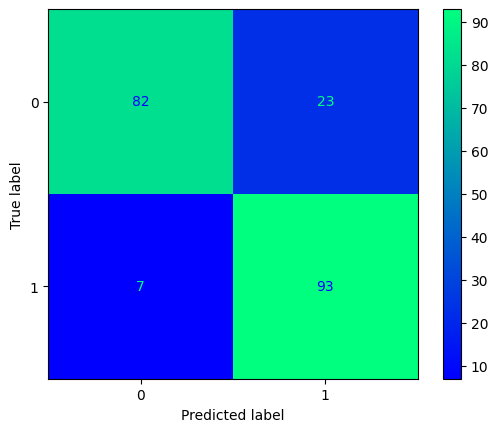

In [51]:
# Confusion Matrix Plot
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logit_reg.classes_)

disp.plot(cmap=plt.cm.winter)
plt.show()

In [52]:
# Confusion Matrix for Decision Tree
cm = confusion_matrix(y_test, decision_pred, labels = decision_tree.classes_)
print('Confusion Matrix for Decision Tree:')
pd.DataFrame(cm)

Confusion Matrix for Decision Tree:


,0,1
0,101,4
1,0,100


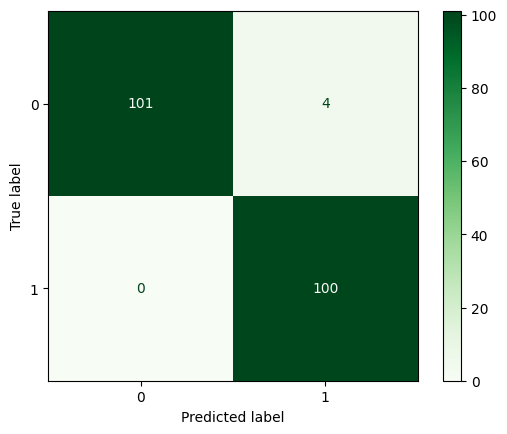

In [56]:
# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(cm, display_labels = decision_tree.classes_)

disp.plot(cmap = plt.cm.Greens)
plt.show()

In [57]:
resultant_df = pd.DataFrame()
resultant_df['Actual Result'] = y_test
resultant_df['Logit Regression Prediction'] = logit_pred
resultant_df['Decisoin Tree Prediction'] = decision_pred
resultant_df.sample(10)

,Actual Result,Logit Regression Prediction,Decisoin Tree Prediction
529,1,1,1
572,1,1,1
423,0,1,0
879,1,1,1
194,0,0,0
438,1,1,1
338,0,1,0
871,1,1,1
969,1,1,1
508,0,0,0


In [58]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [61]:
print(f'Precision Score for Logit Regression: {precision_score(y_test, logit_pred):.3f}')
print(f'Recall Score for Logit Regression: {recall_score(y_test, logit_pred):.3f}')
print(f'F1 Score for Logit Regression: {f1_score(y_test, logit_pred):.3f}')

Precision Score for Logit Regression: 0.802
Recall Score for Logit Regression: 0.930
F1 Score for Logit Regression: 0.861


In [62]:
print(f'Precision Score for Decision Tree: {precision_score(y_test, decision_pred):.3f}')
print(f'Recall Score for Decision Tree: {recall_score(y_test, decision_pred):.3f}')
print(f'F1 Score for Decision Tree: {f1_score(y_test, decision_pred):.3f}')

Precision Score for Decision Tree: 0.962
Recall Score for Decision Tree: 1.000
F1 Score for Decision Tree: 0.980


In [72]:
data = {
    "Metric": ['Accuracy', 'Precision', 'Recall', 'F1'],
    "Logit Regression":[
        accuracy_score(y_test, logit_pred),
        precision_score(y_test, logit_pred),
        recall_score(y_test, logit_pred),
        f1_score(y_test, logit_pred)
    ],
    "Decision Tree":[
        accuracy_score(y_test, decision_pred),
        precision_score(y_test, decision_pred),
        recall_score(y_test, decision_pred),
        f1_score(y_test, decision_pred)
    ]
}


comparison_df = pd.DataFrame(data).set_index('Metric')
comparison_df

,Logit Regression,Decision Tree
Metric,,
Accuracy,0.853659,0.980488
Precision,0.801724,0.961538
Recall,0.930000,1.000000
F1,0.861111,0.980392


In [79]:
precision_score(y_test, decision_pred, average = None),recall_score(y_test, decision_pred, average = None), f1_score(y_test, decision_pred, average = None)

(array([1.        , 0.96153846]),
 array([0.96190476, 1.        ]),
 array([0.98058252, 0.98039216]))

In [80]:
precision_score(y_test, logit_pred, average = None),recall_score(y_test, logit_pred, average = None), f1_score(y_test, logit_pred, average = None)

(array([0.92134831, 0.80172414]),
 array([0.78095238, 0.93      ]),
 array([0.84536082, 0.86111111]))

#### Precision, Recall, and F1 Metrics have three approaches to calculate the score

* `Average = None`
  * Calculate the score for both the positive class and the negative class, but choose the positive class's score
* `Average = 'macro'`
  * Calculate the score for each class separately, and then combine them and divide by the number of classes
* `Average = 'weighted`
  * Calculate the score for each class separately by multiplying the weight by each class, and then combine them; while the weight is calculated as: actual number of instances of each class/total actual number of instances from all classes

---
    